1. Checking local map files...
2. Loading and processing maps...
3. Extracting clean national boundary...
4. Rendering map...
Execution time: 10.74 s


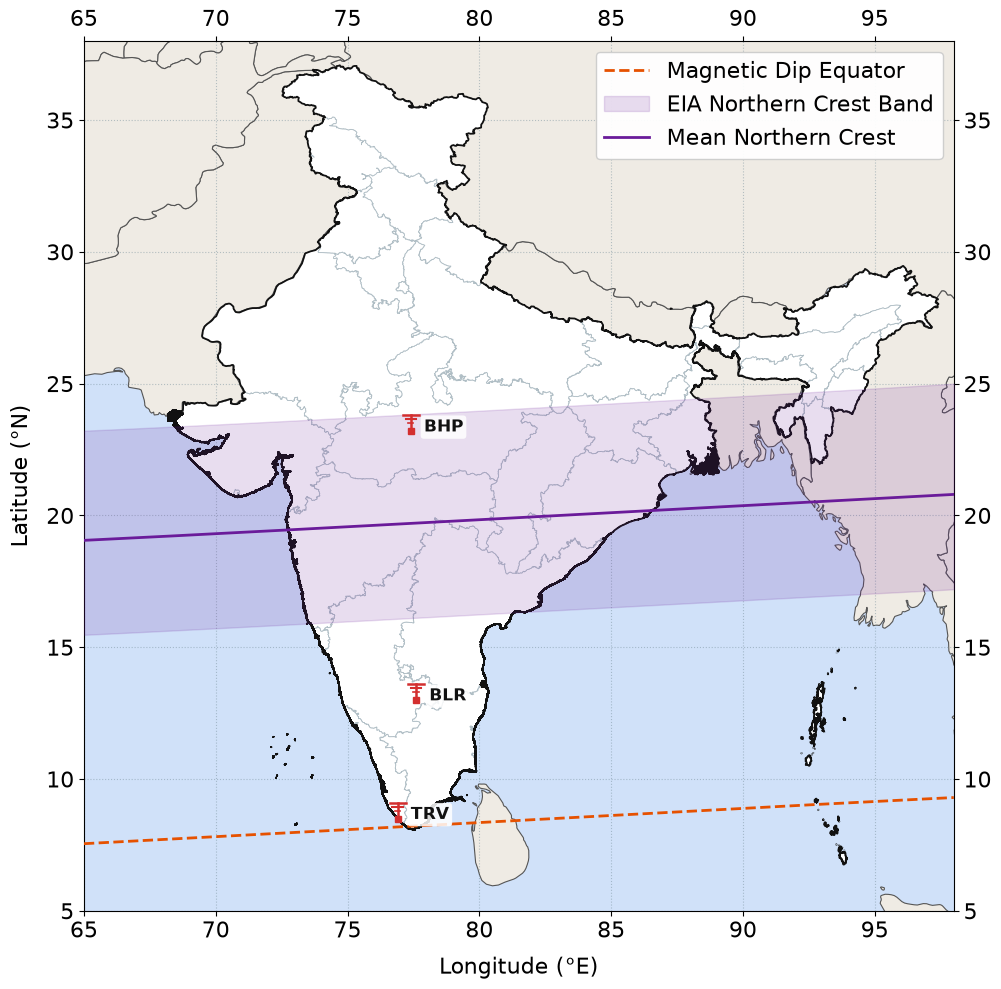

In [2]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
import warnings
import time

warnings.filterwarnings('ignore')
t0 = time.time()

# ==========================================
# 1. LOCAL FILE MANAGEMENT
# ==========================================
print("1. Checking local map files...")
world_filename = "world_map_50m.zip"
india_filename = "india_states_v2.geojson"

world_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
india_url = "https://raw.githubusercontent.com/Amazing-coder1203/BharatMaps/main/india-states-v2.geojson"

if not os.path.exists(world_filename):
    urllib.request.urlretrieve(world_url, world_filename)
if not os.path.exists(india_filename):
    urllib.request.urlretrieve(india_url, india_filename)

# ==========================================
# 2. LOAD & PROCESS MAP GEOMETRIES
# ==========================================
print("2. Loading and processing maps...")
world = gpd.read_file(world_filename)
india_states = gpd.read_file(india_filename)

india_states['geometry'] = india_states.geometry.make_valid()
india_states['geometry'] = india_states.geometry.buffer(0)

world_local = world.cx[60:100, 0:45].copy()
country_col = 'ADMIN' if 'ADMIN' in world_local.columns else 'NAME'
world_no_india = world_local[world_local[country_col] != 'India']

print("3. Extracting clean national boundary...")
india_union = india_states.geometry.union_all()
if isinstance(india_union, MultiPolygon):
    clean_polys = [Polygon(p.exterior) for p in india_union.geoms]
    india_outer = MultiPolygon(clean_polys)
else:
    india_outer = Polygon(india_union.exterior)
india_boundary = gpd.GeoSeries([india_outer])

# ==========================================
# 3. BASEMAP PLOTTING
# ==========================================
print("4. Rendering map...")
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#D0E1F9')
ax.set_xlim([65, 98])
ax.set_ylim([5, 38])
ax.set_aspect('equal')

world_no_india.plot(ax=ax, facecolor='#EFEBE4', edgecolor='#555555', linewidth=0.8, zorder=1)
india_states.plot(ax=ax, facecolor='#FFFFFF', edgecolor='#B0BEC5', linewidth=0.6, zorder=2)
india_boundary.plot(ax=ax, facecolor='none', edgecolor='#111111', linewidth=1.3, zorder=3)

# ==========================================
# 4. CUSTOM ANTENNA DRAWING
# ==========================================
def draw_antenna(ax, lon, lat, name, color='#D32F2F'):
    ax.plot([lon, lon], [lat, lat + 0.6], color=color, lw=1.8, zorder=6)
    ax.plot([lon - 0.30, lon + 0.30], [lat + 0.60, lat + 0.60], color=color, lw=1.8, zorder=6)
    ax.plot([lon - 0.20, lon + 0.20], [lat + 0.45, lat + 0.45], color=color, lw=1.5, zorder=6)
    ax.plot([lon - 0.10, lon + 0.10], [lat + 0.30, lat + 0.30], color=color, lw=1.2, zorder=6)
    ax.plot(lon, lat, marker='s', color=color, markersize=4, zorder=6)
    ax.text(lon + 0.5, lat + 0.15, name, fontsize=12, fontweight='bold', color='#111111', 
            va='center', zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

stations = {
    'TRV': (76.9, 8.5),     #trivandrum
    'BLR': (77.6, 13.0),    #bangalore
    'BHP': (77.4, 23.2),    #bhopal
    # 'HYD': (78.5, 17.4),  #hyderabad
    # 'CDP':(87.02, 21.44), #chandipur   
    # 'DEL': (77.2, 28.6)     #delhi
}

for name, (lon, lat) in stations.items():
    draw_antenna(ax, lon, lat, name, color='#D32F2F')

# ==========================================
# 5. HIGH-RESOLUTION IGRF CONTOURS
# ==========================================
# Pre-computed high-resolution IGRF roots avoiding piecewise linear artifacting
lons = np.linspace(65.0, 98, 31)

dip_eq = np.array([
    # 9.300, 9.243, 9.187, 9.131, 9.076, 9.020, 8.963, 8.905, 8.847, 8.788, 
    # 8.728, 8.669, 8.609, 8.550, 8.490, 8.431, 8.371, 8.312, 8.252, 8.193, 
    # 8.134, 8.075, 8.016, 7.957, 7.898, 7.839, 7.781, 7.722, 7.663, 7.605, 7.547
    7.547,7.605,7.663,7.722,7.781,7.839,7.898,7.957,8.016,8.075,8.134,8.193,8.252,
    8.312,8.371,8.431,8.49,8.55,8.609,8.669,8.728,8.788,8.847,8.905,8.963,9.02,9.076,9.131,9.187,9.243,9.3
])

crest_low = np.array([
    # 19.200, 19.141, 19.083, 19.026, 18.969, 18.911, 18.854, 18.796, 18.738, 18.680, 
    # 18.621, 18.562, 18.503, 18.444, 18.385, 18.326, 18.267, 18.208, 18.149, 18.090, 
    # 18.031, 17.973, 17.915, 17.857, 17.800, 17.743, 17.687, 17.632, 17.577, 17.524, 17.471
    15.471,15.524,15.577,15.632,15.687,15.743,15.8,15.857,15.915,15.973,16.031,16.09,16.149,16.208,16.267,
    16.326,16.385,16.444,16.503,16.562,16.621,16.68,16.738,16.796,16.854,16.911,16.969,17.026,17.083,17.141,17.2
])

crest_avg = np.array([
    # 21.800, 21.737, 21.676, 21.616, 21.558, 21.500, 21.442, 21.385, 21.327, 21.269, 
    # 21.211, 21.152, 21.093, 21.034, 20.975, 20.916, 20.857, 20.798, 20.739, 20.681, 
    # 20.622, 20.564, 20.506, 20.448, 20.390, 20.333, 20.276, 20.220, 20.164, 20.108, 20.053
    19.053,19.108,19.164,19.22,19.276,19.333,19.39,19.448,19.506,19.564,19.622,19.681,19.739,
    19.798,19.857,19.916,19.975,20.034,20.093,20.152,20.211,20.269,20.327,20.385,20.442,20.5,20.558,20.616,20.676,20.737,20.8
])

crest_high = np.array([
    # 24.500, 24.431, 24.364, 24.298, 24.234, 24.171, 24.108, 24.045, 23.983, 23.921, 
    # 23.859, 23.797, 23.736, 23.675, 23.614, 23.553, 23.493, 23.433, 23.374, 23.315, 
    # 23.257, 23.199, 23.141, 23.084, 23.028, 22.973, 22.919, 22.866, 22.814, 22.763, 22.713
    23.213,23.263,23.314,23.366,23.419,23.473,23.528,23.584,23.641,23.699,23.757,23.815,23.874,
    23.933,23.993,24.053,24.114,24.175,24.236,24.297,24.359,24.421,24.483,24.545,24.608,24.671,24.734,24.798,24.864,24.931,25
])

# Use polyfit to generate ultra-smooth, mathematically continuous plot lines
p_dip = np.poly1d(np.polyfit(lons, dip_eq, 4))
p_low = np.poly1d(np.polyfit(lons, crest_low, 4))
p_avg = np.poly1d(np.polyfit(lons, crest_avg, 4))
p_high = np.poly1d(np.polyfit(lons, crest_high, 4))

lons_dense = np.linspace(65, 98, 300)

ax.plot(lons_dense, p_dip(lons_dense), color='#E65100', linewidth=2, linestyle='--', 
        label=r'Magnetic Dip Equator', zorder=4) #($I = 0^\circ$)

ax.fill_between(lons_dense, p_low(lons_dense), p_high(lons_dense), color='#6A1B9A', alpha=0.15, 
                label=r'EIA Northern Crest Band', zorder=3) #($\phi_d \approx 15^\circ - 20^\circ$N)

ax.plot(lons_dense, p_avg(lons_dense), color='#6A1B9A', linewidth=2, linestyle='-', 
        label=r'Mean Northern Crest', zorder=4) #($\phi_d \approx 15^\circ$N, $I \approx 28.2^\circ$)

# ==========================================
# 6. FORMATTING & DISPLAY
# ==========================================
ax.tick_params(top=True, bottom=True, left=True, right=True, 
               labeltop=True, labelbottom=True, labelleft=True,labelsize=16, labelright=True)
ax.grid(True, linestyle=':', color='#78909C', alpha=0.5, zorder=0)

ax.set_xlabel("Longitude (°E)", fontsize=16, labelpad=10)
ax.set_ylabel("Latitude (°N)", fontsize=16, labelpad=10)
plt.legend(loc='upper right', fontsize=16, framealpha=0.95, facecolor='white')
print(f"Execution time: {time.time() - t0:.2f} s")
plt.tight_layout()
plt.savefig("figure1_station_map.pdf", dpi=200)
plt.show()